# Two-Stage Sentiment Classifier — Stock Social Media Posts

Predicts sentiment class (`-1` = Bearish, `0` = Neutral, `1` = Bullish) from post text using a **two-stage pipeline**:

| Stage | Task                                    | Model              | Input                                   |
| ----- | --------------------------------------- | ------------------ | --------------------------------------- |
| **1** | "Has sentiment?" — Sentiment vs Neutral | LinearSVC + TF-IDF | All posts                               |
| **2** | "Which direction?" — Bullish vs Bearish | XGBoost + TF-IDF   | Only posts Stage 1 flagged as sentiment |

Each stage has its own TF-IDF vectorizer (separate vocabularies). The final 3-class prediction combines both stages.

**Metrics reported per stock**: Accuracy, Confusion Matrix, Precision, Recall, F1 Score, MCC


In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    matthews_corrcoef,
)
import xgboost as xgb

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
# ── Configuration ─────────────────────────────────────────────
DATA_DIR = os.path.join("..", "pre-processing")   # path to _final.csv files
STOCKS = ["AAPL", "AMZN", "FB", "NVDA", "TSLA"]
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Train-only neutral capping for Stage 1 (test distribution stays untouched)
NEUTRAL_CAP_MULTIPLIER = 1.5

# TF-IDF settings (separate per stage)
MAX_TFIDF_FEATURES_S1 = 10_000   # Stage 1: Sentiment vs Neutral
MAX_TFIDF_FEATURES_S2 = 5_000    # Stage 2: Bullish vs Bearish

# Label mappings
LABEL_MAP = {-1: "Bearish", 0: "Neutral", 1: "Bullish"}
LABEL_ORDER = [-1, 0, 1]
LABEL_NAMES = ["Bearish", "Neutral", "Bullish"]

# XGBoost needs 0-indexed classes for Stage 2
S2_LABEL_REMAP = {-1: 0, 1: 1}   # Bearish→0, Bullish→1
S2_LABEL_UNMAP = {0: -1, 1: 1}   # 0→Bearish, 1→Bullish

## 1 — Load Data (No Rebalancing), Chronological Sort

Each stock dataset is loaded and sorted by date with no class rebalancing at this stage. Class imbalance is handled later on the training split only, keeping the test set in its original real-world distribution.


In [3]:
# ── Load data only (no rebalancing yet), sort chronologically ──
ts_data = {}

for stock in STOCKS:
    path = os.path.join(DATA_DIR, f"{stock}_final.csv")
    print(f"Loading {stock} from {path} ...")
    df = pd.read_csv(path, low_memory=False)

    # Parse and sort by date
    df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
    df = df.sort_values("created_at").reset_index(drop=True)

    # Drop rows with missing text
    df = df.dropna(subset=["body_no_stopwords"]).reset_index(drop=True)

    counts = df["entities"].value_counts().sort_index()
    print(
        f"  Original:  Bearish={counts.get(-1, 0):>8,}  "
        f"Neutral={counts.get(0, 0):>8,}  Bullish={counts.get(1, 0):>8,}  Total={len(df):>10,}"
    )
    for label_val, count in counts.items():
        pct = count / len(df) * 100
        print(f"    {LABEL_MAP.get(label_val, label_val)}: {count:,} ({pct:.1f}%)")
    print(f"  Date range: {df['created_at'].min()} → {df['created_at'].max()}")
    print()

    ts_data[stock] = df

print("All datasets loaded (no class rebalancing applied yet).")

Loading AAPL from ..\pre-processing\AAPL_final.csv ...
  Original:  Bearish= 107,549  Neutral= 461,513  Bullish= 345,900  Total=   914,962
    Bearish: 107,549 (11.8%)
    Neutral: 461,513 (50.4%)
    Bullish: 345,900 (37.8%)
  Date range: 2019-12-31 21:07:39+00:00 → 2022-02-27 15:17:51+00:00

Loading AMZN from ..\pre-processing\AMZN_final.csv ...
  Original:  Bearish=  48,336  Neutral= 303,319  Bullish= 188,148  Total=   539,803
    Bearish: 48,336 (9.0%)
    Neutral: 303,319 (56.2%)
    Bullish: 188,148 (34.9%)
  Date range: 2019-07-23 21:14:41+00:00 → 2022-03-05 14:16:48+00:00

Loading FB from ..\pre-processing\FB_final.csv ...
  Original:  Bearish=  47,400  Neutral= 198,047  Bullish= 114,461  Total=   359,908
    Bearish: 47,400 (13.2%)
    Neutral: 198,047 (55.0%)
    Bullish: 114,461 (31.8%)
  Date range: 2019-07-23 19:06:54+00:00 → 2022-03-05 06:34:16+00:00

Loading NVDA from ..\pre-processing\NVDA_final.csv ...
  Original:  Bearish=  49,684  Neutral= 342,723  Bullish= 191,771  

## 2 — Chronological 80/20 Split + Train-Only Rebalancing

Data is split by date (first 80% train, last 20% test). The test split remains untouched. Stage 1 training uses a train-only neutral cap (`NEUTRAL_CAP_MULTIPLIER × sentiment_count`) to reduce imbalance without distorting evaluation.


In [4]:
# ── Chronological 80/20 split + train-only neutral capping for Stage 1 ──
ts_frames = {}         # stock -> (train_df_raw, test_df_raw)
ts_train_s1 = {}       # stock -> train_df rebalanced for Stage 1 only

for stock in STOCKS:
    df = ts_data[stock]
    n = len(df)
    split_idx = int(n * (1 - TEST_SIZE))  # 80/20 chronological

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()  # untouched distribution

    print(f"{stock}:")
    print(f"  Train(raw): {len(train_df):,} rows  ({train_df['created_at'].min().date()} -> {train_df['created_at'].max().date()})")
    print(f"  Test(raw):  {len(test_df):,} rows  ({test_df['created_at'].min().date()} -> {test_df['created_at'].max().date()})")

    # Verify no date leakage
    assert train_df["created_at"].max() <= test_df["created_at"].min(), "Date leakage detected!"

    # Stage-1 train-only neutral capping
    train_sent = train_df[train_df["entities"].isin([-1, 1])].copy()
    train_neut = train_df[train_df["entities"] == 0].copy()

    target_neutral = int(len(train_sent) * NEUTRAL_CAP_MULTIPLIER)
    if len(train_neut) > target_neutral:
        idx = np.linspace(0, len(train_neut) - 1, target_neutral, dtype=int)
        train_neut = train_neut.iloc[idx]

    train_s1 = (
        pd.concat([train_sent, train_neut], axis=0)
        .sort_values("created_at")
        .reset_index(drop=True)
    )

    # Show class distribution in raw train/test and Stage-1 train
    for split_label, split_df in [
        ("Train(raw)", train_df),
        ("Train(S1 capped)", train_s1),
        ("Test(raw)", test_df),
    ]:
        counts = split_df["entities"].value_counts().sort_index()
        dist = "  |  ".join(f"{LABEL_MAP[k]}: {v:,}" for k, v in counts.items())
        print(f"  {split_label} classes: {dist}")
    print()

    ts_frames[stock] = (train_df, test_df)
    ts_train_s1[stock] = train_s1

print("Chronological splits ready (test untouched, train-only Stage 1 capping applied).")

AAPL:
  Train(raw): 731,969 rows  (2019-12-31 -> 2021-09-02)
  Test(raw):  182,993 rows  (2021-09-02 -> 2022-02-27)
  Train(raw) classes: Bearish: 82,637  |  Neutral: 370,128  |  Bullish: 279,204
  Train(S1 capped) classes: Bearish: 82,637  |  Neutral: 370,128  |  Bullish: 279,204
  Test(raw) classes: Bearish: 24,912  |  Neutral: 91,385  |  Bullish: 66,696

AMZN:
  Train(raw): 431,842 rows  (2019-07-23 -> 2021-09-27)
  Test(raw):  107,961 rows  (2021-09-27 -> 2022-03-05)
  Train(raw) classes: Bearish: 35,650  |  Neutral: 245,677  |  Bullish: 150,515
  Train(S1 capped) classes: Bearish: 35,650  |  Neutral: 245,677  |  Bullish: 150,515
  Test(raw) classes: Bearish: 12,686  |  Neutral: 57,642  |  Bullish: 37,633

FB:
  Train(raw): 287,926 rows  (2019-07-23 -> 2022-02-02)
  Test(raw):  71,982 rows  (2022-02-02 -> 2022-03-05)
  Train(raw) classes: Bearish: 30,605  |  Neutral: 162,682  |  Bullish: 94,639
  Train(S1 capped) classes: Bearish: 30,605  |  Neutral: 162,682  |  Bullish: 94,639
  T

## 3 — Stage 1: Sentiment vs Neutral (LinearSVC)

Binary classifier: **"Does this post have sentiment?"**

- Labels remapped: Bearish(-1) -> 1, Bullish(1) -> 1, Neutral(0) -> 0
- Uses `ts_train_s1` (train-only capped neutral distribution)
- Own TF-IDF vectorizer (10K features, unigrams + bigrams) fit on training data only
- Test set remains raw chronological distribution


In [5]:
# ── Stage 1: Sentiment vs Neutral (LinearSVC) ─────────────────────────
S1_NAMES = ["Neutral", "Sentiment"]

stage1 = {}  # stock -> dict of model, vectorizer, metrics, predictions

for stock in STOCKS:
    train_df, test_df = ts_frames[stock]  # raw chronological split
    train_s1 = ts_train_s1[stock]         # train-only rebalanced set for Stage 1

    # Remap labels: Bearish(-1)->1, Bullish(1)->1, Neutral(0)->0
    y_train_s1 = (train_s1["entities"] != 0).astype(int).values   # 0=Neutral, 1=Sentiment
    y_test_s1 = (test_df["entities"] != 0).astype(int).values

    # Fit TF-IDF on Stage-1 training text only
    vec_s1 = TfidfVectorizer(
        max_features=MAX_TFIDF_FEATURES_S1,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )
    X_train_s1 = vec_s1.fit_transform(train_s1["body_no_stopwords"])
    X_test_s1 = vec_s1.transform(test_df["body_no_stopwords"])

    # Train LinearSVC
    clf_s1 = LinearSVC(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        dual="auto",
    )
    clf_s1.fit(X_train_s1, y_train_s1)
    y_pred_s1 = clf_s1.predict(X_test_s1)

    # Metrics
    acc = accuracy_score(y_test_s1, y_pred_s1)
    mcc = matthews_corrcoef(y_test_s1, y_pred_s1)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_test_s1, y_pred_s1, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_test_s1, y_pred_s1, labels=[0, 1])

    stage1[stock] = {
        "clf": clf_s1, "vec": vec_s1,
        "accuracy": acc, "mcc": mcc,
        "f1_weighted": f1_w, "precision_weighted": prec_w, "recall_weighted": rec_w,
        "cm": cm, "y_test": y_test_s1, "y_pred": y_pred_s1,
        "X_test": X_test_s1,
    }

    # Print report
    print("=" * 60)
    print(f"  {stock} — Stage 1: Sentiment vs Neutral (LinearSVC)")
    print("=" * 60)
    print(f"  Accuracy : {acc:.4f}   MCC : {mcc:.4f}   F1 (wtd) : {f1_w:.4f}")
    print()
    print(classification_report(
        y_test_s1, y_pred_s1, labels=[0, 1],
        target_names=S1_NAMES, zero_division=0
    ))

    # Key stat: sentiment recall (how many true-sentiment posts does Stage 1 catch?)
    sent_recall = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
    print(f"  Sentiment recall: {sent_recall:.4f} — {cm[1,1]:,} of {cm[1,0]+cm[1,1]:,} sentiment posts forwarded to Stage 2")
    print()

print("Stage 1 complete for all stocks.")

  AAPL — Stage 1: Sentiment vs Neutral (LinearSVC)
  Accuracy : 0.6267   MCC : 0.2556   F1 (wtd) : 0.6249

              precision    recall  f1-score   support

     Neutral       0.65      0.56      0.60     91385
   Sentiment       0.61      0.69      0.65     91608

    accuracy                           0.63    182993
   macro avg       0.63      0.63      0.62    182993
weighted avg       0.63      0.63      0.62    182993

  Sentiment recall: 0.6949 — 63,656 of 91,608 sentiment posts forwarded to Stage 2

  AMZN — Stage 1: Sentiment vs Neutral (LinearSVC)
  Accuracy : 0.6209   MCC : 0.2536   F1 (wtd) : 0.6196

              precision    recall  f1-score   support

     Neutral       0.68      0.55      0.61     57642
   Sentiment       0.58      0.70      0.63     50319

    accuracy                           0.62    107961
   macro avg       0.63      0.63      0.62    107961
weighted avg       0.63      0.62      0.62    107961

  Sentiment recall: 0.7011 — 35,278 of 50,319 se

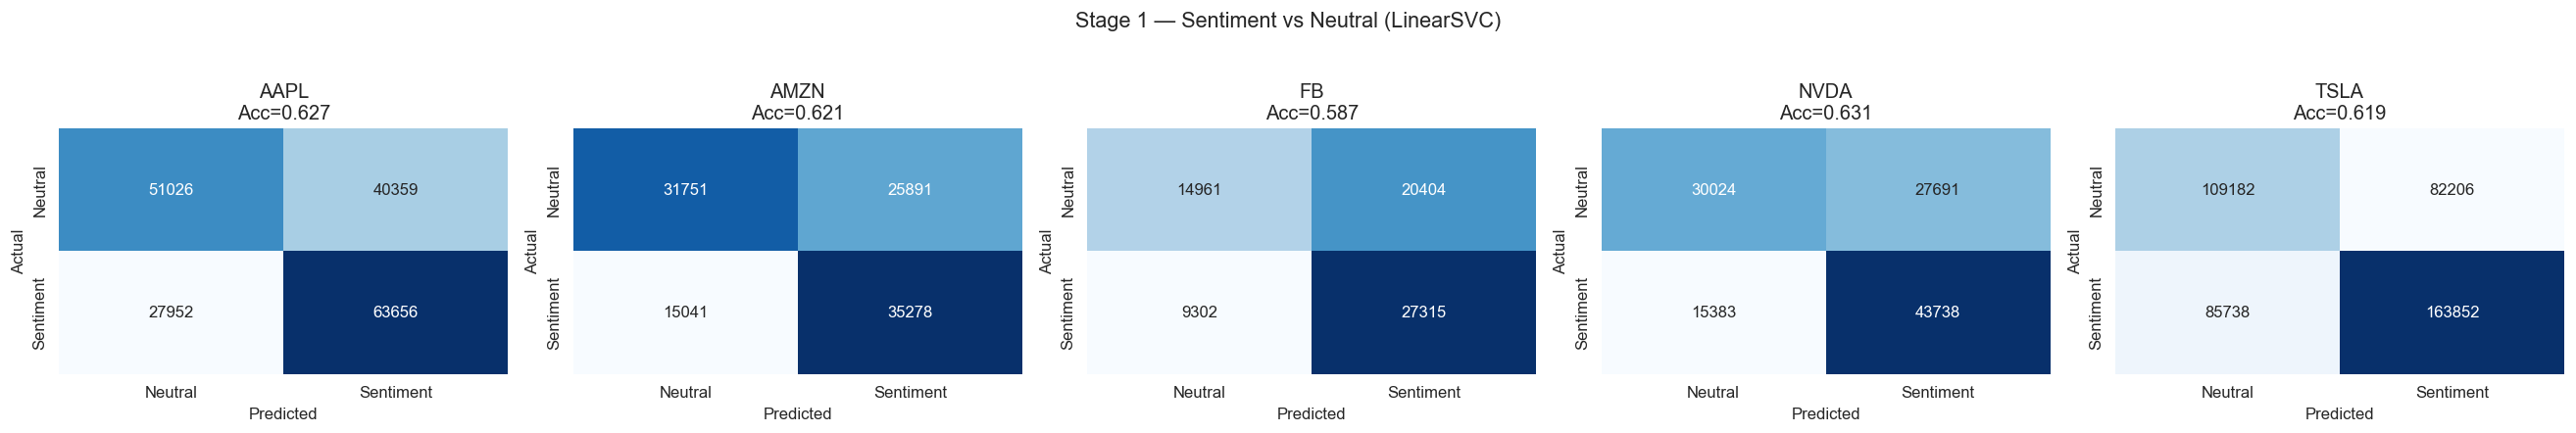

Saved → stage1_confusion_matrices.png


In [6]:
# ── Stage 1 Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 3.5))
fig.suptitle("Stage 1 — Sentiment vs Neutral (LinearSVC)", fontsize=13, y=1.04)

for ax, stock in zip(axes, STOCKS):
    cm = stage1[stock]["cm"]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=S1_NAMES, yticklabels=S1_NAMES,
        ax=ax, cbar=False,
    )
    acc = stage1[stock]["accuracy"]
    ax.set_title(f"{stock}\nAcc={acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("stage1_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → stage1_confusion_matrices.png")

## 4 — Stage 2: Bullish vs Bearish (XGBoost)

Binary classifier: **"Which direction is the sentiment?"**

- **Training**: fit only on Bearish + Bullish rows from the training set (Neutral excluded)
- Own TF-IDF vectorizer (5K features) — learns vocabulary tuned for Bullish-vs-Bearish without neutral noise
- `XGBClassifier` with `sample_weight='balanced'` handles the ~3:1 Bullish:Bearish imbalance
- **Inference**: applied only to test posts that Stage 1 predicted as "has sentiment"


In [7]:
# ── Stage 2: Bullish vs Bearish (XGBoost) ─────────────────────────────
S2_NAMES = ["Bearish", "Bullish"]
S2_ORDER = [-1, 1]

stage2 = {}  # stock → dict of model, vectorizer, metrics, predictions

for stock in STOCKS:
    train_df, test_df = ts_frames[stock]

    # ── Training: only Bearish + Bullish rows ────────────────────────
    train_sent = train_df[train_df["entities"].isin([-1, 1])].copy()
    print(f"{stock} — Stage 2 training on {len(train_sent):,} sentiment rows "
          f"(Bearish={sum(train_sent['entities']==-1):,}, Bullish={sum(train_sent['entities']==1):,})")

    # Fit Stage 2 TF-IDF on sentiment training text only
    vec_s2 = TfidfVectorizer(
        max_features=MAX_TFIDF_FEATURES_S2,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )
    X_train_s2 = vec_s2.fit_transform(train_sent["body_no_stopwords"])
    y_train_s2_raw = train_sent["entities"].values  # -1 or 1

    # Remap for XGBoost: Bearish(-1)→0, Bullish(1)→1
    y_train_s2 = np.array([S2_LABEL_REMAP[y] for y in y_train_s2_raw])

    # Balanced sample weights
    sw = compute_sample_weight("balanced", y_train_s2)

    # Train XGBoost
    clf_s2 = xgb.XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )
    clf_s2.fit(X_train_s2, y_train_s2, sample_weight=sw)

    # ── Evaluate Stage 2 on TRUE sentiment test posts ────────────────
    # (This shows Stage 2 accuracy in isolation, independent of Stage 1 errors)
    test_sent = test_df[test_df["entities"].isin([-1, 1])].copy()
    X_test_s2_true = vec_s2.transform(test_sent["body_no_stopwords"])
    y_test_s2_raw = test_sent["entities"].values
    y_pred_s2_xgb = clf_s2.predict(X_test_s2_true)
    y_pred_s2_raw = np.array([S2_LABEL_UNMAP[y] for y in y_pred_s2_xgb])

    acc = accuracy_score(y_test_s2_raw, y_pred_s2_raw)
    mcc = matthews_corrcoef(y_test_s2_raw, y_pred_s2_raw)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_test_s2_raw, y_pred_s2_raw, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_test_s2_raw, y_pred_s2_raw, labels=S2_ORDER)

    stage2[stock] = {
        "clf": clf_s2, "vec": vec_s2,
        "accuracy": acc, "mcc": mcc,
        "f1_weighted": f1_w, "precision_weighted": prec_w, "recall_weighted": rec_w,
        "cm": cm, "y_test": y_test_s2_raw, "y_pred": y_pred_s2_raw,
    }

    # Print report
    print("=" * 60)
    print(f"  {stock} — Stage 2: Bullish vs Bearish (XGBoost, isolated)")
    print("=" * 60)
    print(f"  Accuracy : {acc:.4f}   MCC : {mcc:.4f}   F1 (wtd) : {f1_w:.4f}")
    print()
    print(classification_report(
        y_test_s2_raw, y_pred_s2_raw, labels=S2_ORDER,
        target_names=S2_NAMES, zero_division=0
    ))

print("Stage 2 complete for all stocks.")

AAPL — Stage 2 training on 361,841 sentiment rows (Bearish=82,637, Bullish=279,204)
  AAPL — Stage 2: Bullish vs Bearish (XGBoost, isolated)
  Accuracy : 0.7668   MCC : 0.3984   F1 (wtd) : 0.7641

              precision    recall  f1-score   support

     Bearish       0.58      0.54      0.56     24912
     Bullish       0.83      0.85      0.84     66696

    accuracy                           0.77     91608
   macro avg       0.70      0.69      0.70     91608
weighted avg       0.76      0.77      0.76     91608

AMZN — Stage 2 training on 186,165 sentiment rows (Bearish=35,650, Bullish=150,515)
  AMZN — Stage 2: Bullish vs Bearish (XGBoost, isolated)
  Accuracy : 0.7784   MCC : 0.4070   F1 (wtd) : 0.7774

              precision    recall  f1-score   support

     Bearish       0.56      0.55      0.55     12686
     Bullish       0.85      0.86      0.85     37633

    accuracy                           0.78     50319
   macro avg       0.71      0.70      0.70     50319
weighte

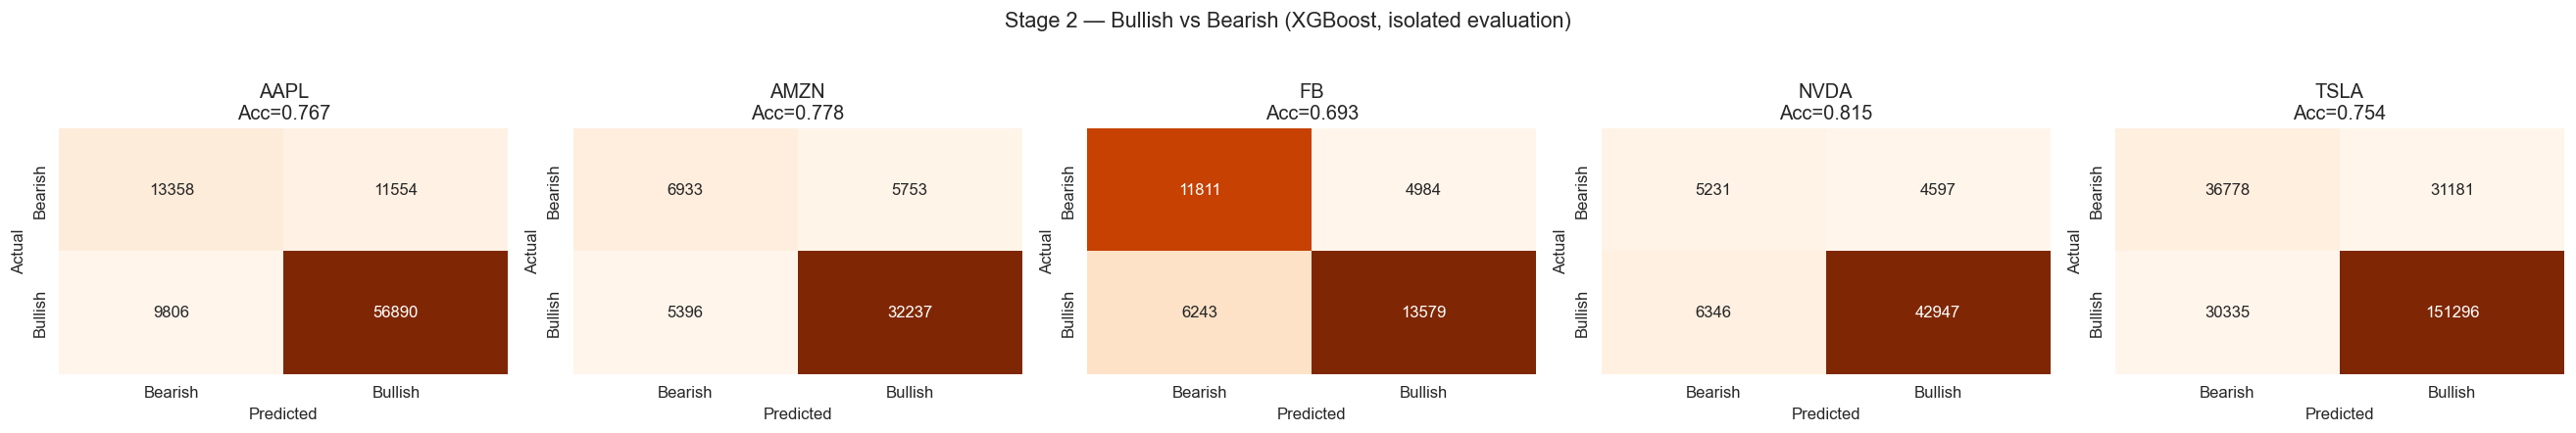

Saved → stage2_confusion_matrices.png


In [8]:
# ── Stage 2 Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 3.5))
fig.suptitle("Stage 2 — Bullish vs Bearish (XGBoost, isolated evaluation)", fontsize=13, y=1.04)

for ax, stock in zip(axes, STOCKS):
    cm = stage2[stock]["cm"]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Oranges",
        xticklabels=S2_NAMES, yticklabels=S2_NAMES,
        ax=ax, cbar=False,
    )
    acc = stage2[stock]["accuracy"]
    ax.set_title(f"{stock}\nAcc={acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("stage2_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → stage2_confusion_matrices.png")

## 5 — Combined Pipeline: 3-Class Evaluation

The two models are **combined at inference time** to produce final 3-class predictions:

1. Stage 1 predicts "Neutral" → final label = **Neutral (0)**
2. Stage 1 predicts "Sentiment" → post goes to Stage 2 → final label = **Bearish (-1)** or **Bullish (1)**

This is the end-to-end evaluation against the true 3-class labels.


In [9]:
# ── Combined Pipeline: merge Stage 1 + Stage 2 → 3-class predictions ──
combined_results = {}

for stock in STOCKS:
    train_df, test_df = ts_frames[stock]
    y_test_true = test_df["entities"].values  # true 3-class labels

    # Stage 1 predictions (0=Neutral, 1=Sentiment)
    y_s1 = stage1[stock]["y_pred"]

    # Indices where Stage 1 predicted "sentiment"
    sent_mask = y_s1 == 1
    n_sent = sent_mask.sum()
    n_neut = (~sent_mask).sum()

    # Build final 3-class prediction array
    y_combined = np.zeros(len(y_test_true), dtype=int)  # default to Neutral (0)

    if n_sent > 0:
        # Get text for posts Stage 1 flagged as sentiment
        test_text_sent = test_df.iloc[sent_mask]["body_no_stopwords"]

        # Transform with Stage 2's TF-IDF and predict
        X_sent_s2 = stage2[stock]["vec"].transform(test_text_sent)
        y_s2_xgb = stage2[stock]["clf"].predict(X_sent_s2)
        y_s2 = np.array([S2_LABEL_UNMAP[y] for y in y_s2_xgb])  # back to -1/1

        # Fill in sentiment predictions
        y_combined[sent_mask] = y_s2

    # ── 3-Class Metrics ──────────────────────────────────────────────
    acc = accuracy_score(y_test_true, y_combined)
    mcc = matthews_corrcoef(y_test_true, y_combined)
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_test_true, y_combined, average="weighted", zero_division=0
    )
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_test_true, y_combined, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_test_true, y_combined, labels=LABEL_ORDER)

    # Per-class recall (recall-first metrics)
    bear_recall = (y_combined[y_test_true == -1] == -1).mean() if (y_test_true == -1).sum() else 0
    bull_recall = (y_combined[y_test_true == 1] == 1).mean()   if (y_test_true == 1).sum() else 0
    neut_recall = (y_combined[y_test_true == 0] == 0).mean()   if (y_test_true == 0).sum() else 0
    sent_catch  = ((y_combined != 0) & (y_test_true != 0)).sum() / (y_test_true != 0).sum() \
                  if (y_test_true != 0).sum() else 0

    combined_results[stock] = {
        "accuracy": acc, "f1_weighted": f1_w, "f1_macro": f1_m,
        "precision_weighted": prec_w, "recall_weighted": rec_w,
        "precision_macro": prec_m, "recall_macro": rec_m,
        "mcc": mcc, "cm": cm,
        "y_test": y_test_true, "y_pred": y_combined,
        "n_sent_predicted": n_sent, "n_neut_predicted": n_neut,
        "bear_recall": bear_recall, "bull_recall": bull_recall,
        "neut_recall": neut_recall, "sent_catch": sent_catch,
    }

    # Print report
    print("=" * 60)
    print(f"  {stock} — Two-Stage Combined (3-Class)")
    print("=" * 60)
    print(f"  Accuracy : {acc:.4f}   MCC : {mcc:.4f}")
    print(f"  F1 (wtd) : {f1_w:.4f}   F1 (macro) : {f1_m:.4f}")
    print(f"  *** RECALL-FIRST METRICS ***")
    print(f"  Bearish recall : {bear_recall:.4f}")
    print(f"  Bullish recall : {bull_recall:.4f}")
    print(f"  Neutral recall : {neut_recall:.4f}")
    print(f"  Sentiment catch: {sent_catch:.4f}")
    print(f"  Stage 1 routed: {n_neut:,} → Neutral  |  {n_sent:,} → Stage 2")
    print()
    print(classification_report(
        y_test_true, y_combined, labels=LABEL_ORDER,
        target_names=LABEL_NAMES, zero_division=0
    ))

print("Combined evaluation complete.")

  AAPL — Two-Stage Combined (3-Class)
  Accuracy : 0.5548   MCC : 0.2688
  F1 (wtd) : 0.5549   F1 (macro) : 0.5050
  *** RECALL-FIRST METRICS ***
  Bearish recall : 0.3345
  Bullish recall : 0.6322
  Neutral recall : 0.5584
  Sentiment catch: 0.6949
  Stage 1 routed: 78,978 → Neutral  |  104,015 → Stage 2

              precision    recall  f1-score   support

     Bearish       0.35      0.33      0.34     24912
     Neutral       0.65      0.56      0.60     91385
     Bullish       0.53      0.63      0.57     66696

    accuracy                           0.55    182993
   macro avg       0.51      0.51      0.51    182993
weighted avg       0.56      0.55      0.55    182993

  AMZN — Two-Stage Combined (3-Class)
  Accuracy : 0.5570   MCC : 0.2663
  F1 (wtd) : 0.5602   F1 (macro) : 0.4993
  *** RECALL-FIRST METRICS ***
  Bearish recall : 0.3360
  Bullish recall : 0.6408
  Neutral recall : 0.5508
  Sentiment catch: 0.7011
  Stage 1 routed: 46,792 → Neutral  |  61,169 → Stage 2

    

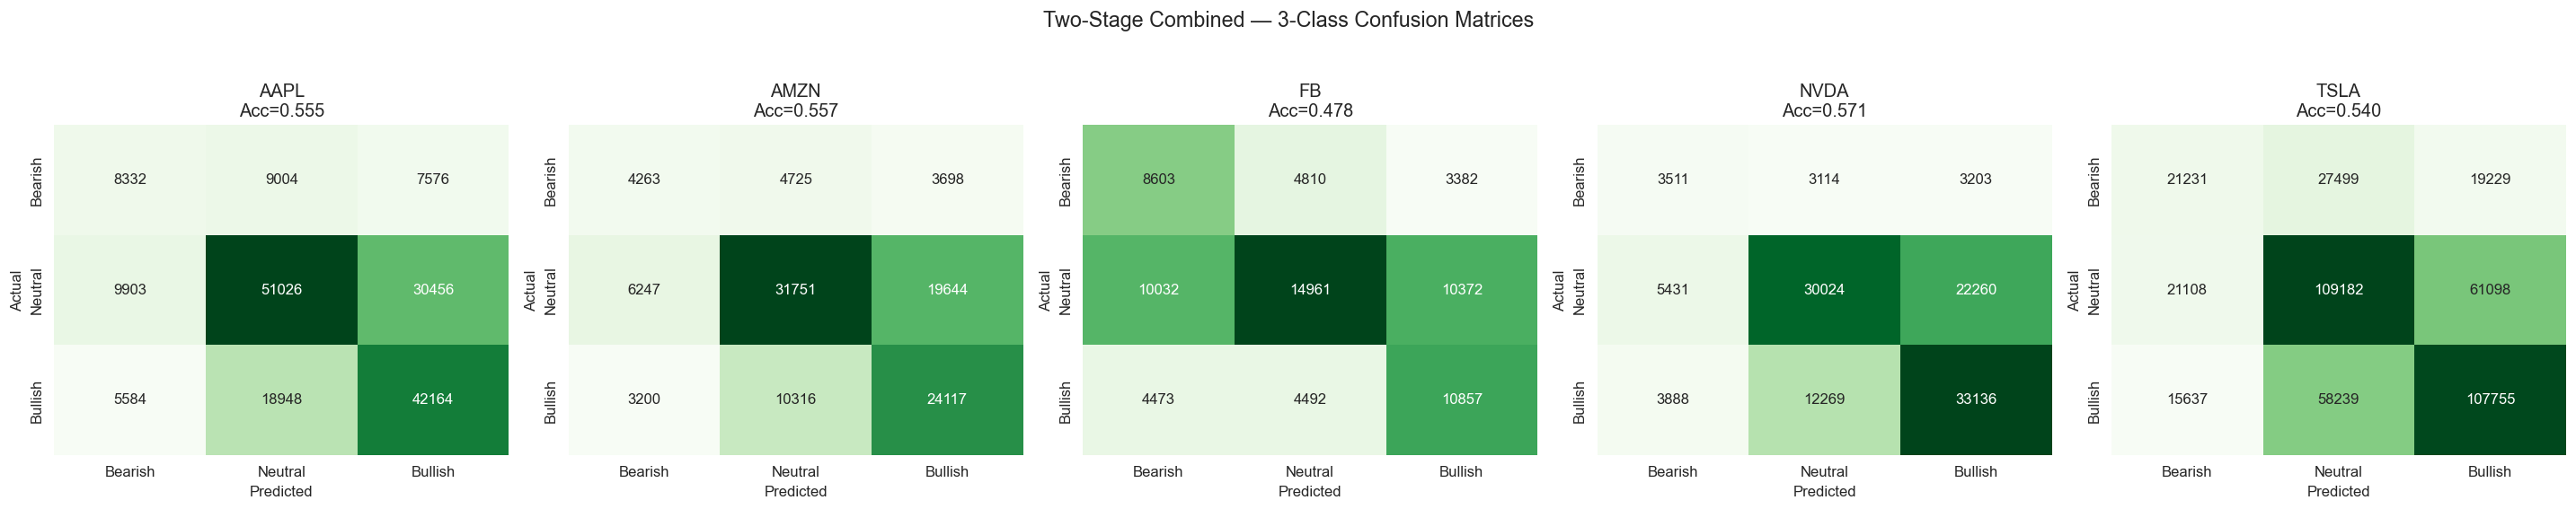

Saved → combined_confusion_matrices.png


In [10]:
# ── Combined 3-Class Confusion Matrices ───────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))
fig.suptitle("Two-Stage Combined — 3-Class Confusion Matrices", fontsize=14, y=1.04)

for ax, stock in zip(axes, STOCKS):
    cm = combined_results[stock]["cm"]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Greens",
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
        ax=ax, cbar=False,
    )
    acc = combined_results[stock]["accuracy"]
    ax.set_title(f"{stock}\nAcc={acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("combined_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → combined_confusion_matrices.png")

## 6 — Error Analysis: Cascade Breakdown

In a two-stage pipeline, errors cascade: if Stage 1 misclassifies a Bullish post as Neutral, it never reaches Stage 2 — that's a guaranteed final error regardless of Stage 2's accuracy.

This analysis breaks down where errors originate:

- **Stage 1 kills**: true sentiment posts wrongly classified as Neutral (lost before Stage 2)
- **Stage 1 leaks**: true Neutral posts wrongly sent to Stage 2
- **Stage 2 flips**: posts correctly routed by Stage 1 but misclassified by Stage 2


In [11]:
# ── Error Analysis: where does the cascade fail? ─────────────────────
error_rows = []

for stock in STOCKS:
    train_df, test_df = ts_frames[stock]
    y_true = test_df["entities"].values       # true 3-class labels
    y_s1   = stage1[stock]["y_pred"]           # Stage 1: 0=Neutral, 1=Sentiment
    y_comb = combined_results[stock]["y_pred"] # final combined prediction

    n_test = len(y_true)

    # True class masks
    true_bearish = y_true == -1
    true_neutral = y_true == 0
    true_bullish = y_true == 1
    true_sentiment = true_bearish | true_bullish

    # Stage 1 errors
    s1_kills = true_sentiment & (y_s1 == 0)   # sentiment → wrongly called Neutral
    s1_leaks = true_neutral & (y_s1 == 1)     # neutral → wrongly sent to Stage 2

    # Stage 2 errors (among posts correctly routed by Stage 1)
    correctly_routed = true_sentiment & (y_s1 == 1)
    s2_flips = correctly_routed & (y_comb != y_true)

    # Total errors
    total_errors = (y_comb != y_true).sum()

    row = {
        "Stock": stock,
        "Test Size": n_test,
        "Total Errors": total_errors,
        "Error Rate": round(total_errors / n_test, 4),
        "S1 Kills (sent→neut)": s1_kills.sum(),
        "S1 Leaks (neut→sent)": s1_leaks.sum(),
        "S2 Flips (wrong dir)": s2_flips.sum(),
        "S1 Kills %": round(s1_kills.sum() / max(total_errors, 1) * 100, 1),
        "S1 Leaks %": round(s1_leaks.sum() / max(total_errors, 1) * 100, 1),
        "S2 Flips %": round(s2_flips.sum() / max(total_errors, 1) * 100, 1),
    }
    error_rows.append(row)

    print(f"\n{'='*60}")
    print(f"  {stock} — Error Breakdown ({total_errors:,} total errors of {n_test:,} test posts)")
    print(f"{'='*60}")
    print(f"  Stage 1 kills (true sentiment → predicted Neutral):  {s1_kills.sum():>6,}  ({row['S1 Kills %']:5.1f}% of errors)")
    print(f"    - Bearish killed:  {(true_bearish & (y_s1==0)).sum():,}")
    print(f"    - Bullish killed:  {(true_bullish & (y_s1==0)).sum():,}")
    print(f"  Stage 1 leaks (true Neutral → sent to Stage 2):     {s1_leaks.sum():>6,}  ({row['S1 Leaks %']:5.1f}% of errors)")
    print(f"  Stage 2 flips (correct route, wrong direction):     {s2_flips.sum():>6,}  ({row['S2 Flips %']:5.1f}% of errors)")

    # Sentiment recall = % of true sentiment posts that made it to Stage 2
    sent_recall = 1 - s1_kills.sum() / max(true_sentiment.sum(), 1)
    print(f"\n  Sentiment recall (S1): {sent_recall:.4f} — bounds overall accuracy")

error_df = pd.DataFrame(error_rows).set_index("Stock")
print("\n" + "=" * 70)
print("  ERROR BREAKDOWN SUMMARY")
print("=" * 70)
display(error_df)


  AAPL — Error Breakdown (81,471 total errors of 182,993 test posts)
  Stage 1 kills (true sentiment → predicted Neutral):  27,952  ( 34.3% of errors)
    - Bearish killed:  9,004
    - Bullish killed:  18,948
  Stage 1 leaks (true Neutral → sent to Stage 2):     40,359  ( 49.5% of errors)
  Stage 2 flips (correct route, wrong direction):     13,160  ( 16.2% of errors)

  Sentiment recall (S1): 0.6949 — bounds overall accuracy

  AMZN — Error Breakdown (47,830 total errors of 107,961 test posts)
  Stage 1 kills (true sentiment → predicted Neutral):  15,041  ( 31.4% of errors)
    - Bearish killed:  4,725
    - Bullish killed:  10,316
  Stage 1 leaks (true Neutral → sent to Stage 2):     25,891  ( 54.1% of errors)
  Stage 2 flips (correct route, wrong direction):      6,898  ( 14.4% of errors)

  Sentiment recall (S1): 0.7011 — bounds overall accuracy

  FB — Error Breakdown (37,561 total errors of 71,982 test posts)
  Stage 1 kills (true sentiment → predicted Neutral):   9,302  ( 24.8

,Test Size,Total Errors,Error Rate,S1 Kills (sent→neut),S1 Leaks (neut→sent),S2 Flips (wrong dir),S1 Kills %,S1 Leaks %,S2 Flips %
Stock,,,,,,,,,
AAPL,182993,81471,0.4452,27952,40359,13160,34.3,49.5,16.2
AMZN,107961,47830,0.4430,15041,25891,6898,31.4,54.1,14.4
FB,71982,37561,0.5218,9302,20404,7855,24.8,54.3,20.9
NVDA,116836,50165,0.4294,15383,27691,7091,30.7,55.2,14.1
TSLA,440978,202810,0.4599,85738,82206,34866,42.3,40.5,17.2


## 7 — Summary Table & Comparison Charts

Per-stock and cross-stock metrics for both stages and the combined pipeline.


In [12]:
# ── Summary Table ─────────────────────────────────────────────────────
summary_rows = []
for stock in STOCKS:
    s1 = stage1[stock]
    s2 = stage2[stock]
    cb = combined_results[stock]

    summary_rows.append({
        "Stock": stock,
        "S1 Acc (Sent/Neut)": round(s1["accuracy"], 4),
        "S1 F1 (wtd)": round(s1["f1_weighted"], 4),
        "S1 MCC": round(s1["mcc"], 4),
        "S2 Acc (Bull/Bear)": round(s2["accuracy"], 4),
        "S2 F1 (wtd)": round(s2["f1_weighted"], 4),
        "S2 MCC": round(s2["mcc"], 4),
        "Combined Acc": round(cb["accuracy"], 4),
        "Combined F1 (wtd)": round(cb["f1_weighted"], 4),
        "Combined F1 (macro)": round(cb["f1_macro"], 4),
        "Combined MCC": round(cb["mcc"], 4),
        "Bear Recall": round(cb["bear_recall"], 4),
        "Bull Recall": round(cb["bull_recall"], 4),
        "Neut Recall": round(cb["neut_recall"], 4),
        "Sent Catch": round(cb["sent_catch"], 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Stock")

print("=" * 80)
print("  TWO-STAGE CLASSIFIER — FULL SUMMARY")
print("=" * 80)
display(summary_df)

  TWO-STAGE CLASSIFIER — FULL SUMMARY


,S1 Acc (Sent/Neut),S1 F1 (wtd),S1 MCC,S2 Acc (Bull/Bear),S2 F1 (wtd),S2 MCC,Combined Acc,Combined F1 (wtd),Combined F1 (macro),Combined MCC,Bear Recall,Bull Recall,Neut Recall,Sent Catch
Stock,,,,,,,,,,,,,,
AAPL,0.6267,0.6249,0.2556,0.7668,0.7641,0.3984,0.5548,0.5549,0.5050,0.2688,0.3345,0.6322,0.5584,0.6949
AMZN,0.6209,0.6196,0.2536,0.7784,0.7774,0.4070,0.5570,0.5602,0.4993,0.2663,0.3360,0.6408,0.5508,0.7011
FB,0.5873,0.5761,0.1787,0.6934,0.6939,0.3870,0.4782,0.4817,0.4739,0.2218,0.5122,0.5477,0.4230,0.7460
NVDA,0.6313,0.6267,0.2667,0.8149,0.8208,0.3786,0.5706,0.5729,0.5022,0.2730,0.3572,0.6722,0.5202,0.7398
TSLA,0.6192,0.6195,0.2265,0.7535,0.7530,0.3756,0.5401,0.5374,0.4951,0.2490,0.3124,0.5933,0.5705,0.6565


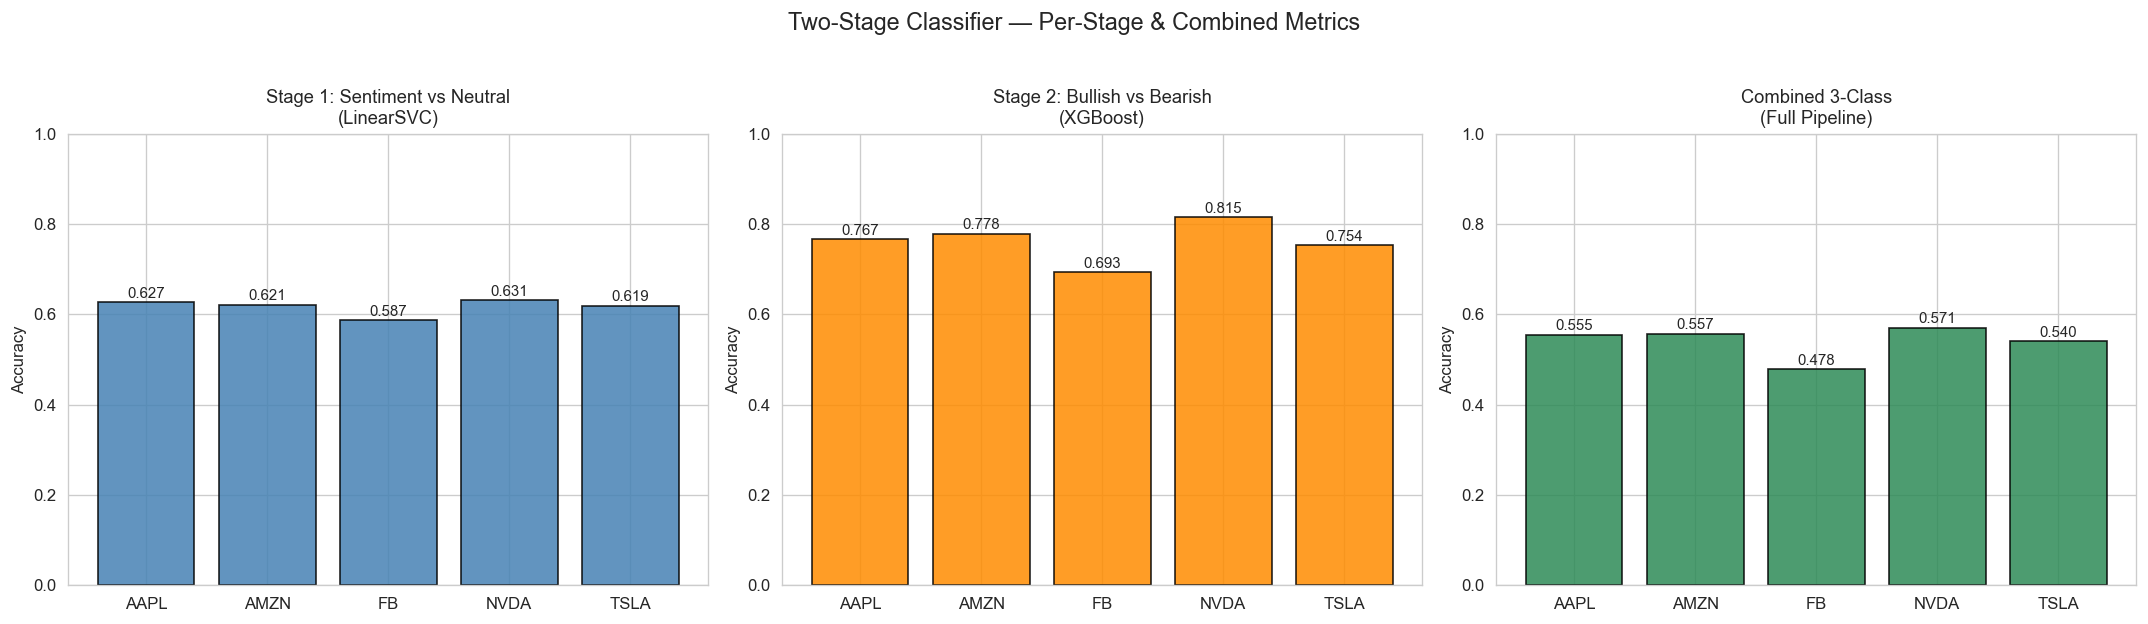

Saved → two_stage_accuracy_comparison.png


In [13]:
# ── Comparison Bar Charts ─────────────────────────────────────────────
# Chart 1: Per-stage accuracy comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Two-Stage Classifier — Per-Stage & Combined Metrics", fontsize=14, y=1.03)

# Stage 1 Accuracy
ax = axes[0]
s1_accs = [stage1[s]["accuracy"] for s in STOCKS]
bars = ax.bar(STOCKS, s1_accs, color="steelblue", edgecolor="black", alpha=0.85)
ax.set_title("Stage 1: Sentiment vs Neutral\n(LinearSVC)", fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
for i, v in enumerate(s1_accs):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

# Stage 2 Accuracy
ax = axes[1]
s2_accs = [stage2[s]["accuracy"] for s in STOCKS]
bars = ax.bar(STOCKS, s2_accs, color="darkorange", edgecolor="black", alpha=0.85)
ax.set_title("Stage 2: Bullish vs Bearish\n(XGBoost)", fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
for i, v in enumerate(s2_accs):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

# Combined 3-class accuracy
ax = axes[2]
cb_accs = [combined_results[s]["accuracy"] for s in STOCKS]
bars = ax.bar(STOCKS, cb_accs, color="seagreen", edgecolor="black", alpha=0.85)
ax.set_title("Combined 3-Class\n(Full Pipeline)", fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Accuracy")
for i, v in enumerate(cb_accs):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("two_stage_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → two_stage_accuracy_comparison.png")

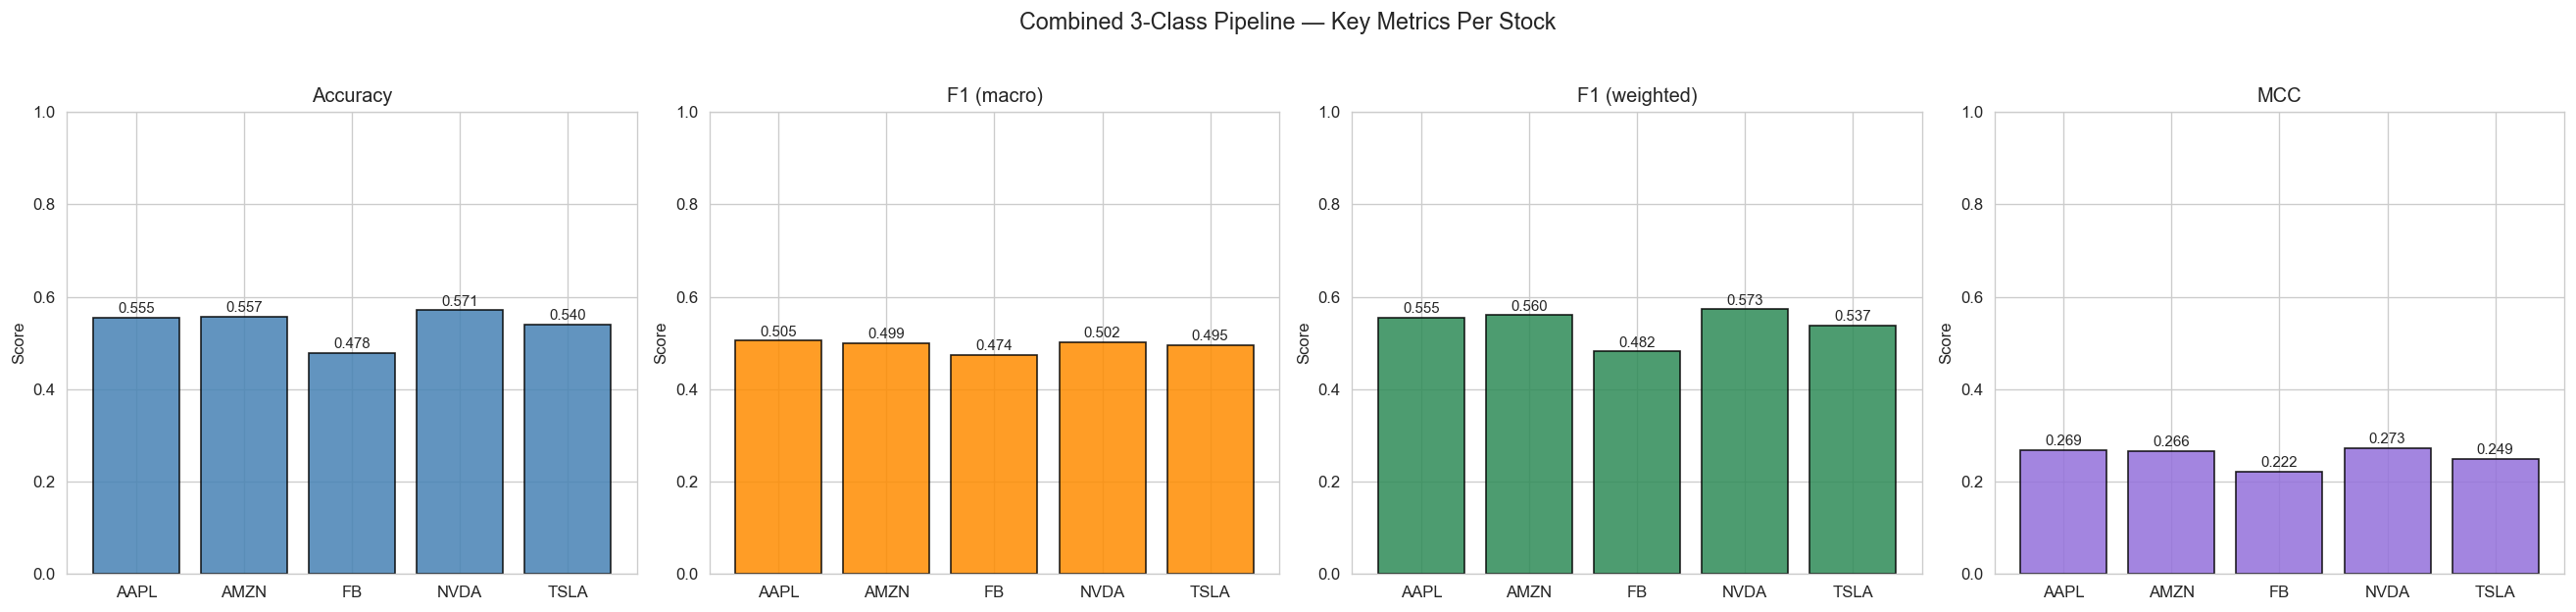

Saved → two_stage_combined_metrics.png


In [14]:
# ── Combined Metrics Bar Chart (Accuracy, F1 macro, F1 weighted, MCC) ──
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Combined 3-Class Pipeline — Key Metrics Per Stock", fontsize=14, y=1.03)

metrics_chart = [
    ("Accuracy", "accuracy", "steelblue"),
    ("F1 (macro)", "f1_macro", "darkorange"),
    ("F1 (weighted)", "f1_weighted", "seagreen"),
    ("MCC", "mcc", "mediumpurple"),
]

for ax, (label, key, color) in zip(axes, metrics_chart):
    vals = [combined_results[s][key] for s in STOCKS]
    ax.bar(STOCKS, vals, color=color, edgecolor="black", alpha=0.85)
    ax.set_title(label, fontsize=12)
    ax.set_ylim(0, max(1.0, max(vals) * 1.15))
    ax.set_ylabel("Score")
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("two_stage_combined_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → two_stage_combined_metrics.png")

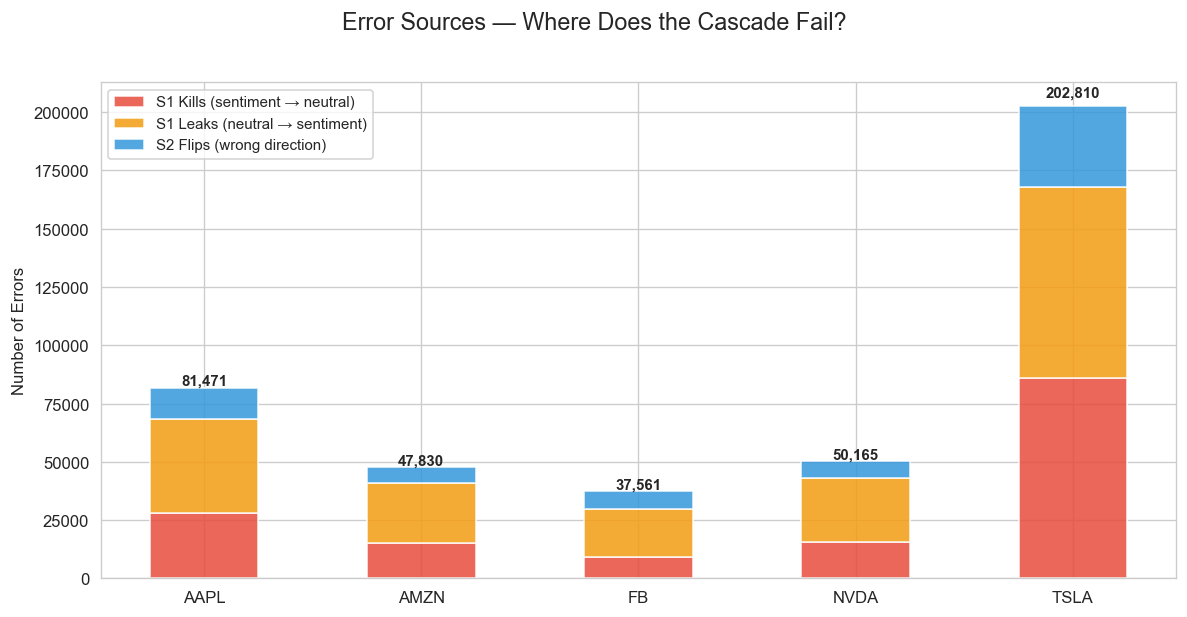

Saved → error_source_breakdown.png


In [15]:
# ── Error Source Stacked Bar Chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Error Sources — Where Does the Cascade Fail?", fontsize=14, y=1.02)

x = np.arange(len(STOCKS))
width = 0.5

s1_kills = [error_df.loc[s, "S1 Kills (sent→neut)"] for s in STOCKS]
s1_leaks = [error_df.loc[s, "S1 Leaks (neut→sent)"] for s in STOCKS]
s2_flips = [error_df.loc[s, "S2 Flips (wrong dir)"] for s in STOCKS]

ax.bar(x, s1_kills, width, label="S1 Kills (sentiment → neutral)", color="#e74c3c", alpha=0.85)
ax.bar(x, s1_leaks, width, bottom=s1_kills, label="S1 Leaks (neutral → sentiment)", color="#f39c12", alpha=0.85)
ax.bar(x, s2_flips, width,
       bottom=[a + b for a, b in zip(s1_kills, s1_leaks)],
       label="S2 Flips (wrong direction)", color="#3498db", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(STOCKS)
ax.set_ylabel("Number of Errors")
ax.legend(loc="upper left", fontsize=9)

# Add total error count labels
for i in range(len(STOCKS)):
    total = s1_kills[i] + s1_leaks[i] + s2_flips[i]
    ax.text(i, total + total * 0.02, f"{total:,}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("error_source_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → error_source_breakdown.png")

---

# Recall-First Experiment Suite

The sections below re-run the pipeline with a focus on **bullish/bearish recall** as the primary objective.

| Experiment | Description                                                                           |
| ---------- | ------------------------------------------------------------------------------------- |
| **A**      | Current pipeline + recall-first metric reporting                                      |
| **B**      | Stage-1 threshold sweep — maximize sentiment recall with acceptable neutral precision |
| **C**      | Stage-2 threshold / class-weight sweep — maximize min(bearish_recall, bullish_recall) |
| **D**      | Direct 3-class linear baseline with same TF-IDF features                              |
| **Final**  | Select best model on validation; report test metrics once                             |


## 8 — Train / Validation / Test Split (Chronological)

Split the existing **training** data further into **train** and **validation** using a chronological cut. All threshold tuning and model selection happen on validation; the held-out test set is touched **only once** at the very end.


In [16]:
# ── 8  Train / Validation / Test Split ──────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

VAL_FRAC = 0.15  # last 15 % of the training set becomes validation

tv_frames = {}          # stock -> (train_df, val_df, test_df)  — all raw
tv_train_s1 = {}        # stock -> train_df with Stage-1 neutral cap (no val rows)

for stock in STOCKS:
    raw_train, test_df = ts_frames[stock]
    n_train = len(raw_train)
    val_idx = int(n_train * (1 - VAL_FRAC))

    train_df = raw_train.iloc[:val_idx].copy()
    val_df   = raw_train.iloc[val_idx:].copy()

    # Stage-1 neutral capping (only on training portion, val stays raw)
    tr_sent = train_df[train_df["entities"].isin([-1, 1])].copy()
    tr_neut = train_df[train_df["entities"] == 0].copy()
    target_neut = int(len(tr_sent) * NEUTRAL_CAP_MULTIPLIER)
    if len(tr_neut) > target_neut:
        idx = np.linspace(0, len(tr_neut) - 1, target_neut, dtype=int)
        tr_neut = tr_neut.iloc[idx]
    train_s1 = pd.concat([tr_sent, tr_neut]).sort_values("created_at").reset_index(drop=True)

    tv_frames[stock] = (train_df, val_df, test_df)
    tv_train_s1[stock] = train_s1

    print(f"{stock}:  Train={len(train_df):,}  Val={len(val_df):,}  Test={len(test_df):,}")
    for lbl, sdf in [("Train(S1)", train_s1), ("Val(raw)", val_df), ("Test(raw)", test_df)]:
        c = sdf["entities"].value_counts().sort_index()
        print(f"  {lbl}: " + "  |  ".join(f"{LABEL_MAP[k]}: {v:,}" for k, v in c.items()))
    print()

print("Train / Val / Test splits ready.")

AAPL:  Train=622,173  Val=109,796  Test=182,993
  Train(S1): Bearish: 68,267  |  Neutral: 320,178  |  Bullish: 233,728
  Val(raw): Bearish: 14,370  |  Neutral: 49,950  |  Bullish: 45,476
  Test(raw): Bearish: 24,912  |  Neutral: 91,385  |  Bullish: 66,696

AMZN:  Train=367,065  Val=64,777  Test=107,961
  Train(S1): Bearish: 30,365  |  Neutral: 210,542  |  Bullish: 126,158
  Val(raw): Bearish: 5,285  |  Neutral: 35,135  |  Bullish: 24,357
  Test(raw): Bearish: 12,686  |  Neutral: 57,642  |  Bullish: 37,633

FB:  Train=244,737  Val=43,189  Test=71,982
  Train(S1): Bearish: 26,394  |  Neutral: 140,441  |  Bullish: 77,902
  Val(raw): Bearish: 4,211  |  Neutral: 22,241  |  Bullish: 16,737
  Test(raw): Bearish: 16,795  |  Neutral: 35,365  |  Bullish: 19,822

NVDA:  Train=397,240  Val=70,102  Test=116,836
  Train(S1): Bearish: 35,383  |  Neutral: 223,905  |  Bullish: 113,887
  Val(raw): Bearish: 4,473  |  Neutral: 37,038  |  Bullish: 28,591
  Test(raw): Bearish: 9,828  |  Neutral: 57,715  |  

## 9 — Experiment B: Stage-1 Threshold Sweep

Instead of using the default decision boundary (0) from `LinearSVC`, we **calibrate** the model and then sweep a threshold on `P(sentiment)` to find the point that **maximizes sentiment recall** while keeping a minimum neutral precision floor. This directly reduces the number of sentiment posts lost at Stage 1.


In [17]:
# ── 9  Experiment B – Stage-1 calibration + threshold sweep ─────────────
NEUTRAL_PREC_FLOOR = 0.40   # accept neutral precision >= 40 %

exp_b = {}   # stock -> best threshold, calibrated model, val metrics

for stock in STOCKS:
    train_df, val_df, test_df = tv_frames[stock]
    train_s1 = tv_train_s1[stock]

    y_train = (train_s1["entities"] != 0).astype(int).values
    y_val   = (val_df["entities"] != 0).astype(int).values

    vec = TfidfVectorizer(max_features=MAX_TFIDF_FEATURES_S1,
                          ngram_range=(1, 2), sublinear_tf=True)
    X_train = vec.fit_transform(train_s1["body_no_stopwords"])
    X_val   = vec.transform(val_df["body_no_stopwords"])

    base_clf = LinearSVC(max_iter=2000, class_weight="balanced",
                         random_state=RANDOM_STATE, dual="auto")
    cal_clf  = CalibratedClassifierCV(base_clf, cv=3, method="sigmoid")
    cal_clf.fit(X_train, y_train)

    probs_val = cal_clf.predict_proba(X_val)[:, 1]  # P(sentiment)

    # Sweep thresholds
    best_thresh, best_sent_rec, best_neut_prec = 0.5, 0.0, 0.0
    thresholds = np.arange(0.10, 0.91, 0.01)
    sweep_rows = []
    for t in thresholds:
        preds = (probs_val >= t).astype(int)
        sent_mask = (y_val == 1)
        neut_mask = (y_val == 0)
        sent_recall = preds[sent_mask].sum() / sent_mask.sum() if sent_mask.sum() else 0
        neut_preds  = (preds == 0)
        neut_prec   = y_val[neut_preds == True].tolist().count(0) / neut_preds.sum() if neut_preds.sum() else 0
        sweep_rows.append({"threshold": round(t, 2),
                           "sent_recall": round(sent_recall, 4),
                           "neut_precision": round(neut_prec, 4)})
        if neut_prec >= NEUTRAL_PREC_FLOOR and sent_recall > best_sent_rec:
            best_thresh  = round(t, 2)
            best_sent_rec = sent_recall
            best_neut_prec = neut_prec

    sweep_df = pd.DataFrame(sweep_rows)

    exp_b[stock] = {
        "cal_clf": cal_clf, "vec": vec,
        "best_threshold": best_thresh,
        "best_sent_recall": best_sent_rec,
        "best_neut_precision": best_neut_prec,
        "sweep_df": sweep_df,
    }

    print(f"{stock} — Best S1 threshold = {best_thresh}  "
          f"(Sent recall = {best_sent_rec:.4f}, Neutral prec = {best_neut_prec:.4f})")

print("\nStage-1 threshold sweep complete.")

AAPL — Best S1 threshold = 0.1  (Sent recall = 0.9999, Neutral prec = 0.9942)
AMZN — Best S1 threshold = 0.1  (Sent recall = 0.9995, Neutral prec = 0.9910)
FB — Best S1 threshold = 0.1  (Sent recall = 0.9997, Neutral prec = 0.9928)
NVDA — Best S1 threshold = 0.1  (Sent recall = 0.9998, Neutral prec = 0.9833)
TSLA — Best S1 threshold = 0.1  (Sent recall = 1.0000, Neutral prec = 0.9966)

Stage-1 threshold sweep complete.


## 10 — Experiment C: Stage-2 Threshold + Class-Weight Sweep

Stage 2 is retrained on the **train** subset using balanced sample weights. We then sweep the XGBoost probability threshold on the **validation** set, optimizing for **min(bearish_recall, bullish_recall)** — ensuring neither direction is neglected.


In [18]:
# ── 10  Experiment C – Stage-2 threshold sweep ──────────────────────────

exp_c = {}

for stock in STOCKS:
    train_df, val_df, test_df = tv_frames[stock]

    # Train Stage-2 on train split (only sentiment rows)
    tr_sent = train_df[train_df["entities"].isin([-1, 1])].copy()
    vec_s2  = TfidfVectorizer(max_features=MAX_TFIDF_FEATURES_S2,
                              ngram_range=(1, 2), sublinear_tf=True)
    X_tr  = vec_s2.fit_transform(tr_sent["body_no_stopwords"])
    y_raw = tr_sent["entities"].values
    y_tr  = np.array([S2_LABEL_REMAP[y] for y in y_raw])
    sw    = compute_sample_weight("balanced", y_tr)

    clf_s2 = xgb.XGBClassifier(objective="binary:logistic",
                                n_estimators=300, max_depth=6,
                                learning_rate=0.1, eval_metric="logloss",
                                random_state=RANDOM_STATE, n_jobs=-1,
                                verbosity=0)
    clf_s2.fit(X_tr, y_tr, sample_weight=sw)

    # Evaluate on validation sentiment posts
    val_sent = val_df[val_df["entities"].isin([-1, 1])].copy()
    X_val_s2 = vec_s2.transform(val_sent["body_no_stopwords"])
    y_val_raw = val_sent["entities"].values
    probs_val = clf_s2.predict_proba(X_val_s2)[:, 1]   # P(Bullish)

    # Sweep threshold for P(Bullish) — below threshold → Bearish
    best_t, best_obj = 0.5, 0.0
    sweep_rows = []
    for t in np.arange(0.20, 0.81, 0.01):
        preds_xgb = (probs_val >= t).astype(int)
        preds_raw = np.array([S2_LABEL_UNMAP[p] for p in preds_xgb])
        bear_mask = (y_val_raw == -1)
        bull_mask = (y_val_raw == 1)
        bear_rec = (preds_raw[bear_mask] == -1).sum() / bear_mask.sum() if bear_mask.sum() else 0
        bull_rec = (preds_raw[bull_mask] == 1).sum() / bull_mask.sum() if bull_mask.sum() else 0
        obj = min(bear_rec, bull_rec)
        sweep_rows.append({"threshold": round(t, 2),
                           "bear_recall": round(bear_rec, 4),
                           "bull_recall": round(bull_rec, 4),
                           "min_recall": round(obj, 4)})
        if obj > best_obj:
            best_t = round(t, 2)
            best_obj = obj

    sweep_df = pd.DataFrame(sweep_rows)

    exp_c[stock] = {
        "clf": clf_s2, "vec": vec_s2,
        "best_threshold": best_t,
        "best_min_recall": best_obj,
        "sweep_df": sweep_df,
    }

    print(f"{stock} — Best S2 threshold = {best_t}  (min(bear,bull) recall = {best_obj:.4f})")

print("\nStage-2 threshold sweep complete.")

AAPL — Best S2 threshold = 0.55  (min(bear,bull) recall = 0.6150)
AMZN — Best S2 threshold = 0.54  (min(bear,bull) recall = 0.6627)
FB — Best S2 threshold = 0.51  (min(bear,bull) recall = 0.6894)
NVDA — Best S2 threshold = 0.54  (min(bear,bull) recall = 0.6193)
TSLA — Best S2 threshold = 0.53  (min(bear,bull) recall = 0.5882)

Stage-2 threshold sweep complete.


## 11 — Experiment D: Direct 3-Class Baseline + Majority Baseline

Two diagnostic baselines:

1. **Majority baseline** — always predict the most common class.
2. **Direct 3-class LogisticRegression** — same TF-IDF features, no cascade.

These prove whether the cascade is actually learning beyond class priors and whether a simpler model could match performance.


In [19]:
# ── 11  Experiment D – Baselines ────────────────────────────────────────

baseline_results = {}

for stock in STOCKS:
    train_df, val_df, test_df = tv_frames[stock]
    y_val = val_df["entities"].values

    # ── Majority baseline ────────────────────────────────────────────
    majority_class = train_df["entities"].value_counts().idxmax()
    maj_preds = np.full(len(y_val), majority_class)
    maj_acc = accuracy_score(y_val, maj_preds)
    maj_mcc = matthews_corrcoef(y_val, maj_preds)
    _, _, maj_f1_w, _ = precision_recall_fscore_support(y_val, maj_preds,
                                                         average="weighted", zero_division=0)
    _, _, maj_f1_m, _ = precision_recall_fscore_support(y_val, maj_preds,
                                                         average="macro", zero_division=0)
    # Per-class recall
    bear_rec_maj = (maj_preds[y_val == -1] == -1).mean() if (y_val == -1).sum() else 0
    bull_rec_maj = (maj_preds[y_val == 1] == 1).mean()   if (y_val == 1).sum() else 0
    neut_rec_maj = (maj_preds[y_val == 0] == 0).mean()   if (y_val == 0).sum() else 0

    # ── 3-class Logistic Regression (balanced) ───────────────────────
    vec_3c = TfidfVectorizer(max_features=MAX_TFIDF_FEATURES_S1,
                             ngram_range=(1, 2), sublinear_tf=True)
    X_tr = vec_3c.fit_transform(train_df["body_no_stopwords"])
    y_tr = train_df["entities"].values
    X_vl = vec_3c.transform(val_df["body_no_stopwords"])

    lr = LogisticRegression(max_iter=1000, class_weight="balanced",
                            random_state=RANDOM_STATE, n_jobs=-1)
    lr.fit(X_tr, y_tr)
    lr_preds = lr.predict(X_vl)

    lr_acc = accuracy_score(y_val, lr_preds)
    lr_mcc = matthews_corrcoef(y_val, lr_preds)
    _, _, lr_f1_w, _ = precision_recall_fscore_support(y_val, lr_preds,
                                                        average="weighted", zero_division=0)
    _, _, lr_f1_m, _ = precision_recall_fscore_support(y_val, lr_preds,
                                                        average="macro", zero_division=0)
    bear_rec_lr = (lr_preds[y_val == -1] == -1).mean() if (y_val == -1).sum() else 0
    bull_rec_lr = (lr_preds[y_val == 1] == 1).mean()   if (y_val == 1).sum() else 0
    neut_rec_lr = (lr_preds[y_val == 0] == 0).mean()   if (y_val == 0).sum() else 0

    baseline_results[stock] = {
        "majority": {
            "accuracy": maj_acc, "mcc": maj_mcc,
            "f1_weighted": maj_f1_w, "f1_macro": maj_f1_m,
            "bear_recall": bear_rec_maj, "bull_recall": bull_rec_maj,
            "neut_recall": neut_rec_maj,
        },
        "lr_3class": {
            "accuracy": lr_acc, "mcc": lr_mcc,
            "f1_weighted": lr_f1_w, "f1_macro": lr_f1_m,
            "bear_recall": bear_rec_lr, "bull_recall": bull_rec_lr,
            "neut_recall": neut_rec_lr,
            "model": lr, "vec": vec_3c,
        },
    }

    print(f"{'='*60}")
    print(f"  {stock} — Baselines (Validation Set)")
    print(f"{'='*60}")
    print(f"  Majority ({LABEL_MAP[majority_class]}): Acc={maj_acc:.4f}  MCC={maj_mcc:.4f}  "
          f"F1w={maj_f1_w:.4f}  F1m={maj_f1_m:.4f}")
    print(f"    Bear recall={bear_rec_maj:.4f}  Bull recall={bull_rec_maj:.4f}  Neut recall={neut_rec_maj:.4f}")
    print(f"  3-Class LR:     Acc={lr_acc:.4f}  MCC={lr_mcc:.4f}  "
          f"F1w={lr_f1_w:.4f}  F1m={lr_f1_m:.4f}")
    print(f"    Bear recall={bear_rec_lr:.4f}  Bull recall={bull_rec_lr:.4f}  Neut recall={neut_rec_lr:.4f}")
    print()

print("Baselines complete.")

g:\Users\jzweb\miniconda3\envs\ml_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  AAPL — Baselines (Validation Set)
  Majority (Neutral): Acc=0.4549  MCC=0.0000  F1w=0.2845  F1m=0.2085
    Bear recall=0.0000  Bull recall=0.0000  Neut recall=1.0000
  3-Class LR:     Acc=0.5647  MCC=0.3106  F1w=0.5678  F1m=0.5333
    Bear recall=0.5150  Bull recall=0.6603  Neut recall=0.4920



g:\Users\jzweb\miniconda3\envs\ml_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  AMZN — Baselines (Validation Set)
  Majority (Neutral): Acc=0.5424  MCC=0.0000  F1w=0.3815  F1m=0.2344
    Bear recall=0.0000  Bull recall=0.0000  Neut recall=1.0000
  3-Class LR:     Acc=0.5338  MCC=0.2787  F1w=0.5525  F1m=0.4851
    Bear recall=0.5716  Bull recall=0.6286  Neut recall=0.4625



g:\Users\jzweb\miniconda3\envs\ml_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  FB — Baselines (Validation Set)
  Majority (Neutral): Acc=0.5150  MCC=0.0000  F1w=0.3501  F1m=0.2266
    Bear recall=0.0000  Bull recall=0.0000  Neut recall=1.0000
  3-Class LR:     Acc=0.5337  MCC=0.2964  F1w=0.5448  F1m=0.4949
    Bear recall=0.5934  Bull recall=0.6726  Neut recall=0.4179



g:\Users\jzweb\miniconda3\envs\ml_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  NVDA — Baselines (Validation Set)
  Majority (Neutral): Acc=0.5283  MCC=0.0000  F1w=0.3653  F1m=0.2305
    Bear recall=0.0000  Bull recall=0.0000  Neut recall=1.0000
  3-Class LR:     Acc=0.5454  MCC=0.2645  F1w=0.5556  F1m=0.4830
    Bear recall=0.5252  Bull recall=0.6716  Neut recall=0.4504



g:\Users\jzweb\miniconda3\envs\ml_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  TSLA — Baselines (Validation Set)
  Majority (Neutral): Acc=0.4375  MCC=0.0000  F1w=0.2663  F1m=0.2029
    Bear recall=0.0000  Bull recall=0.0000  Neut recall=1.0000
  3-Class LR:     Acc=0.5304  MCC=0.2746  F1w=0.5337  F1m=0.5085
    Bear recall=0.5719  Bull recall=0.6202  Neut recall=0.4304

Baselines complete.


## 12 — Final Test Report: Optimized Pipeline vs Baselines

Using the **best thresholds** selected on validation (Experiments B + C), run the tuned two-stage cascade **once** on the held-out test set. Compare against baselines and the original (untuned) pipeline. Report recall-first metrics prominently.


In [20]:
# ── 12  Final Test Report ───────────────────────────────────────────────

final_report = {}

for stock in STOCKS:
    train_df, val_df, test_df = tv_frames[stock]
    y_test = test_df["entities"].values

    # ── A) Tuned Cascade (Exp B + C thresholds) ─────────────────────
    s1_info = exp_b[stock]
    s2_info = exp_c[stock]

    # Stage 1: calibrated model with tuned threshold
    X_test_s1 = s1_info["vec"].transform(test_df["body_no_stopwords"])
    probs_s1 = s1_info["cal_clf"].predict_proba(X_test_s1)[:, 1]
    s1_preds = (probs_s1 >= s1_info["best_threshold"]).astype(int)  # 1=sentiment

    # Build 3-class predictions: posts predicted neutral stay 0
    final_preds = np.zeros(len(y_test), dtype=int)

    sent_mask = (s1_preds == 1)
    if sent_mask.sum() > 0:
        X_sent_s2 = s2_info["vec"].transform(
            test_df.loc[sent_mask, "body_no_stopwords"])
        probs_s2 = s2_info["clf"].predict_proba(X_sent_s2)[:, 1]
        s2_preds_bin = (probs_s2 >= s2_info["best_threshold"]).astype(int)
        s2_preds_raw = np.array([S2_LABEL_UNMAP[p] for p in s2_preds_bin])
        final_preds[np.where(sent_mask)[0]] = s2_preds_raw

    # Metrics
    cascade_acc = accuracy_score(y_test, final_preds)
    cascade_mcc = matthews_corrcoef(y_test, final_preds)
    _, _, cascade_f1w, _ = precision_recall_fscore_support(
        y_test, final_preds, average="weighted", zero_division=0)
    _, _, cascade_f1m, _ = precision_recall_fscore_support(
        y_test, final_preds, average="macro", zero_division=0)
    bear_rec = (final_preds[y_test == -1] == -1).mean() if (y_test == -1).sum() else 0
    bull_rec = (final_preds[y_test == 1] == 1).mean()   if (y_test == 1).sum() else 0
    neut_rec = (final_preds[y_test == 0] == 0).mean()   if (y_test == 0).sum() else 0
    sent_rec = ((final_preds != 0) & (y_test != 0)).sum() / (y_test != 0).sum() \
               if (y_test != 0).sum() else 0

    # ── B) 3-Class LR baseline on test ──────────────────────────────
    bl = baseline_results[stock]["lr_3class"]
    lr_preds_test = bl["model"].predict(bl["vec"].transform(
        test_df["body_no_stopwords"]))
    lr_acc_t = accuracy_score(y_test, lr_preds_test)
    lr_mcc_t = matthews_corrcoef(y_test, lr_preds_test)
    _, _, lr_f1w_t, _ = precision_recall_fscore_support(
        y_test, lr_preds_test, average="weighted", zero_division=0)
    _, _, lr_f1m_t, _ = precision_recall_fscore_support(
        y_test, lr_preds_test, average="macro", zero_division=0)
    bear_rec_lr_t = (lr_preds_test[y_test == -1] == -1).mean() if (y_test == -1).sum() else 0
    bull_rec_lr_t = (lr_preds_test[y_test == 1] == 1).mean()   if (y_test == 1).sum() else 0
    neut_rec_lr_t = (lr_preds_test[y_test == 0] == 0).mean()   if (y_test == 0).sum() else 0

    # ── C) Majority baseline on test ─────────────────────────────────
    maj_class = train_df["entities"].value_counts().idxmax()
    maj_preds_t = np.full(len(y_test), maj_class)
    maj_acc_t = accuracy_score(y_test, maj_preds_t)

    final_report[stock] = {
        "cascade": {
            "accuracy": cascade_acc, "mcc": cascade_mcc,
            "f1_weighted": cascade_f1w, "f1_macro": cascade_f1m,
            "bear_recall": bear_rec, "bull_recall": bull_rec,
            "neut_recall": neut_rec, "sent_recall": sent_rec,
            "s1_threshold": s1_info["best_threshold"],
            "s2_threshold": s2_info["best_threshold"],
        },
        "lr_3class": {
            "accuracy": lr_acc_t, "mcc": lr_mcc_t,
            "f1_weighted": lr_f1w_t, "f1_macro": lr_f1m_t,
            "bear_recall": bear_rec_lr_t, "bull_recall": bull_rec_lr_t,
            "neut_recall": neut_rec_lr_t,
        },
        "majority_acc": maj_acc_t,
        "predictions": final_preds,
        "y_test": y_test,
    }

    print(f"\n{'='*70}")
    print(f"  {stock} — FINAL TEST SET REPORT")
    print(f"{'='*70}")
    print(f"  Majority baseline accuracy : {maj_acc_t:.4f}")
    print(f"  3-Class LR (balanced)      : Acc={lr_acc_t:.4f}  MCC={lr_mcc_t:.4f}")
    print(f"    Bear={bear_rec_lr_t:.4f}  Bull={bull_rec_lr_t:.4f}  Neut={neut_rec_lr_t:.4f}")
    print(f"  Tuned Cascade (B+C)        : Acc={cascade_acc:.4f}  MCC={cascade_mcc:.4f}")
    print(f"    Bear={bear_rec:.4f}  Bull={bull_rec:.4f}  Neut={neut_rec:.4f}  SentCatch={sent_rec:.4f}")
    print(f"    S1 thresh={s1_info['best_threshold']}  S2 thresh={s2_info['best_threshold']}")
    print(f"    F1w={cascade_f1w:.4f}  F1m={cascade_f1m:.4f}")

print("\n\nFinal test evaluation complete — test set touched ONCE.")


  AAPL — FINAL TEST SET REPORT
  Majority baseline accuracy : 0.4994
  3-Class LR (balanced)      : Acc=0.5213  MCC=0.2661
    Bear=0.5223  Bull=0.6232  Neut=0.4466
  Tuned Cascade (B+C)        : Acc=0.3183  MCC=0.1400
    Bear=0.7840  Bull=0.5620  Neut=0.0135  SentCatch=1.0000
    S1 thresh=0.1  S2 thresh=0.55
    F1w=0.2393  F1m=0.2812

  AMZN — FINAL TEST SET REPORT
  Majority baseline accuracy : 0.5339
  3-Class LR (balanced)      : Acc=0.5047  MCC=0.2626
    Bear=0.6179  Bull=0.5956  Neut=0.4205
  Tuned Cascade (B+C)        : Acc=0.3221  MCC=0.1616
    Bear=0.7974  Bull=0.6141  Neut=0.0268  SentCatch=0.9997
    S1 thresh=0.1  S2 thresh=0.54
    F1w=0.2437  F1m=0.2900

  FB — FINAL TEST SET REPORT
  Majority baseline accuracy : 0.4913
  3-Class LR (balanced)      : Acc=0.4614  MCC=0.2446
    Bear=0.6575  Bull=0.6026  Neut=0.2891
  Tuned Cascade (B+C)        : Acc=0.3546  MCC=0.1789
    Bear=0.7412  Bull=0.6457  Neut=0.0078  SentCatch=0.9998
    S1 thresh=0.1  S2 thresh=0.51
    F1

## 13 — Experiment Comparison Summary

Side-by-side bar charts comparing all approaches on the test set across key recall-first metrics.


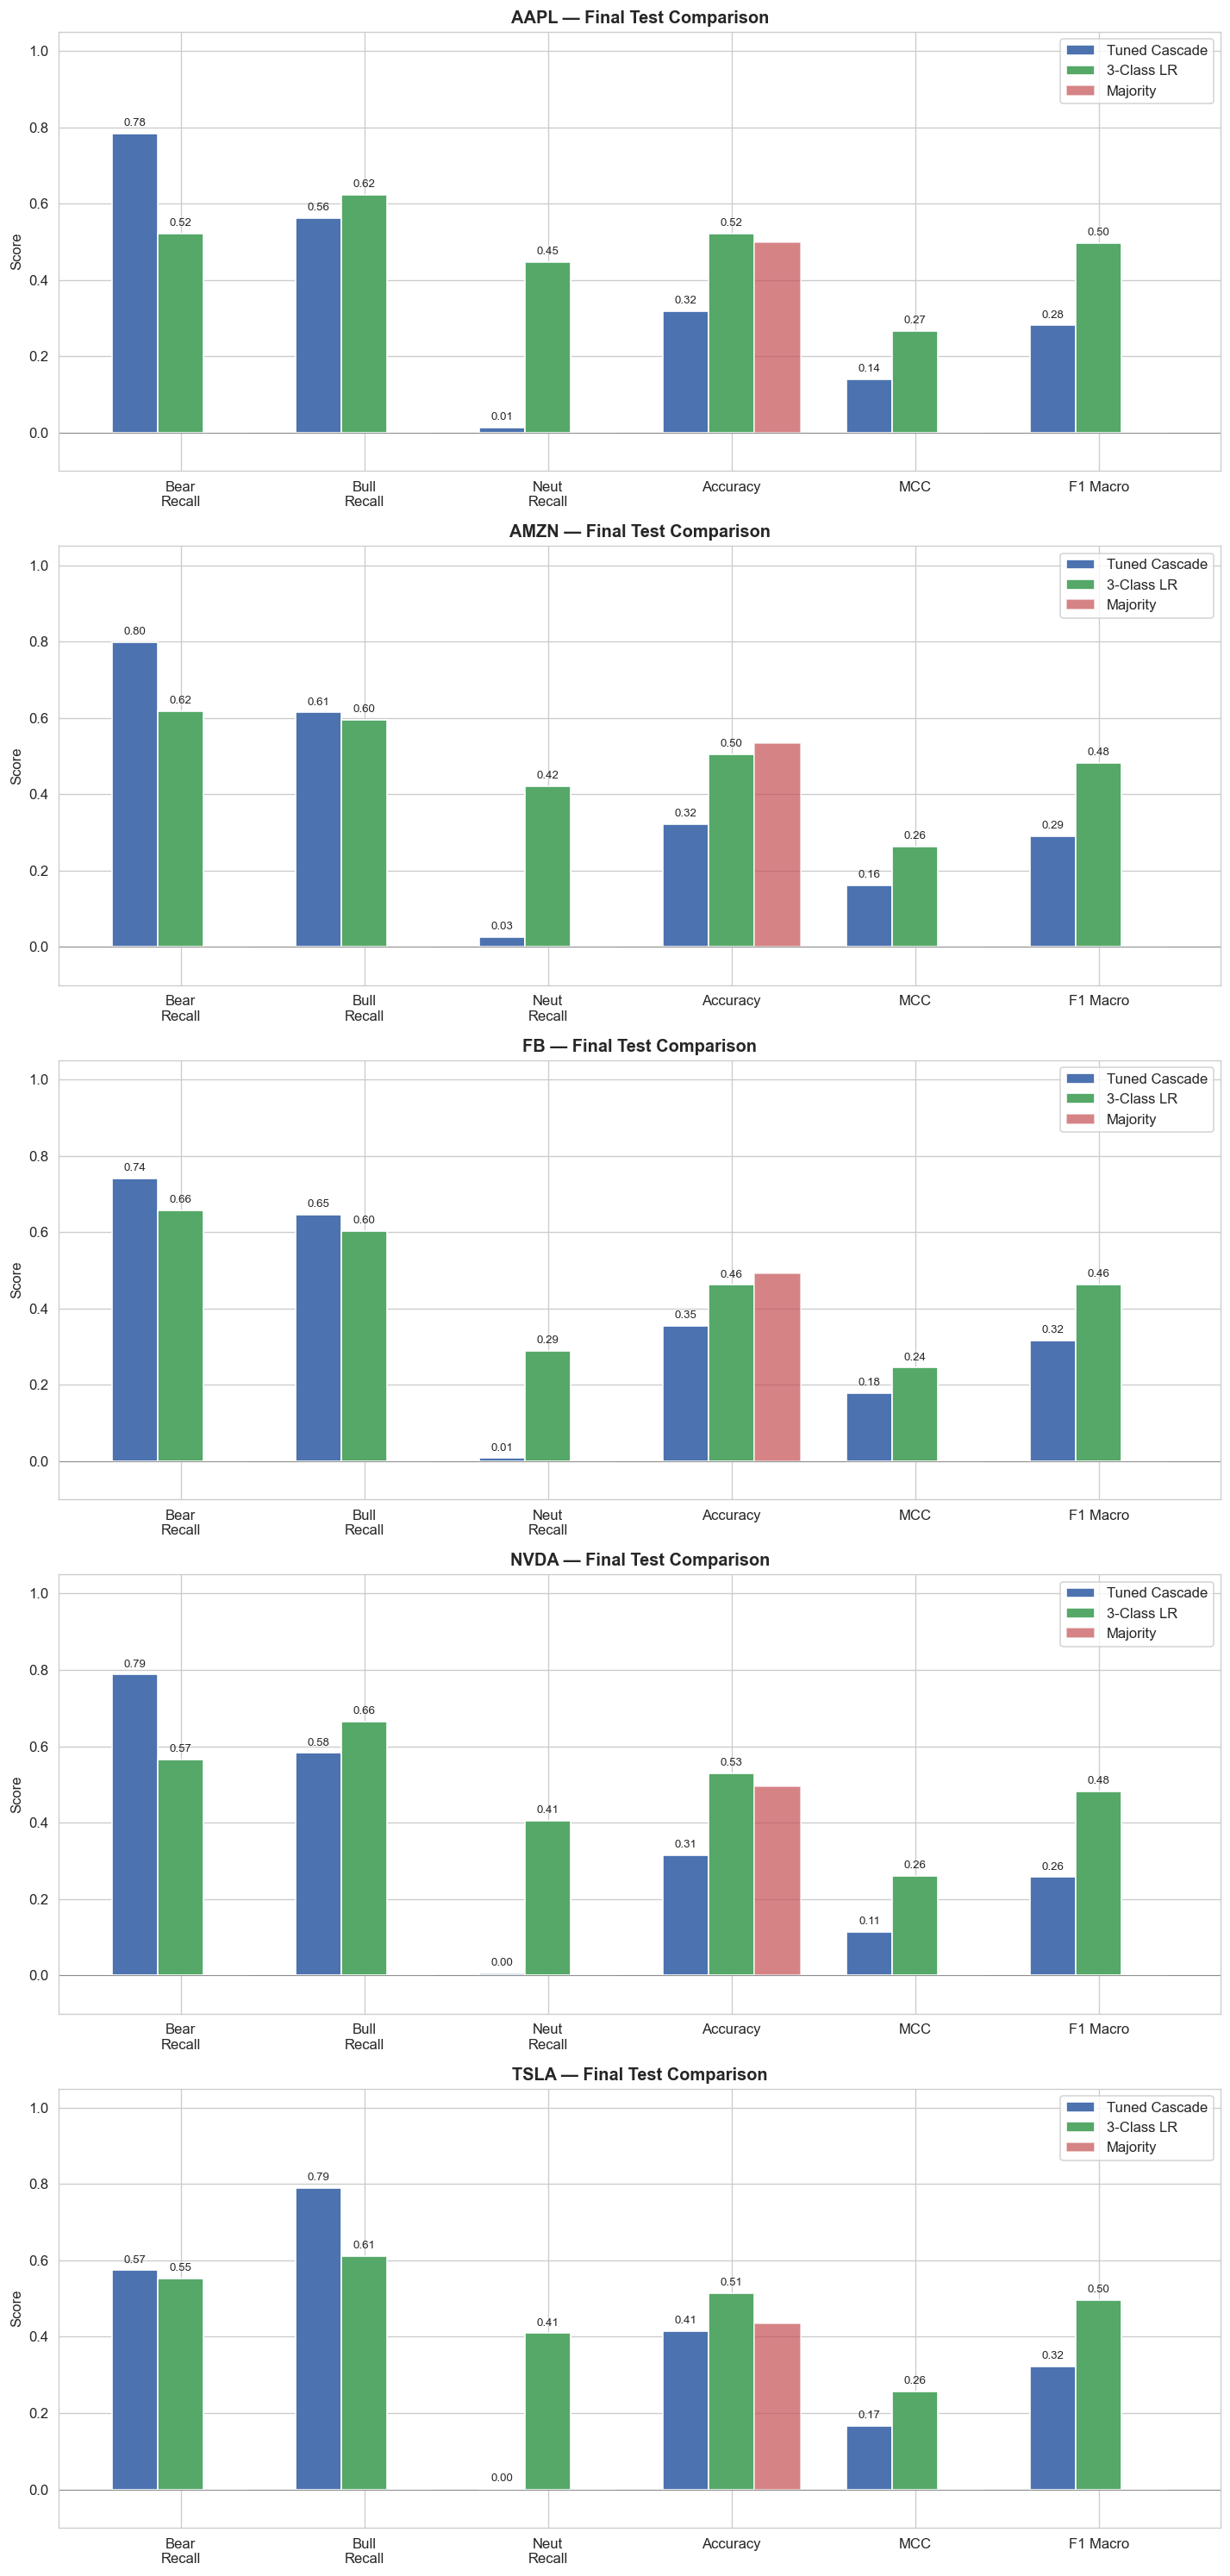

Saved experiment_comparison_summary.png


In [21]:
# ── 13  Experiment Comparison Visualization ─────────────────────────────

fig, axes = plt.subplots(len(STOCKS), 1, figsize=(12, 5 * len(STOCKS)))
if len(STOCKS) == 1:
    axes = [axes]

metrics_list = ["bear_recall", "bull_recall", "neut_recall", "accuracy", "mcc", "f1_macro"]
labels_pretty = ["Bear\nRecall", "Bull\nRecall", "Neut\nRecall", "Accuracy", "MCC", "F1 Macro"]

for ax, stock in zip(axes, STOCKS):
    rpt = final_report[stock]

    # Gather values for each approach
    cascade_vals = [rpt["cascade"][m] for m in metrics_list]
    lr_vals      = [rpt["lr_3class"][m] for m in metrics_list]
    maj_vals     = [rpt["majority_acc"] if m == "accuracy" else 0
                    for m in metrics_list]

    x = np.arange(len(metrics_list))
    w = 0.25

    ax.bar(x - w, cascade_vals, w, label="Tuned Cascade", color="#4C72B0")
    ax.bar(x,     lr_vals,      w, label="3-Class LR",    color="#55A868")
    ax.bar(x + w, maj_vals,     w, label="Majority",      color="#C44E52", alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(labels_pretty)
    ax.set_ylim(-0.1, 1.05)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_ylabel("Score")
    ax.set_title(f"{stock} — Final Test Comparison", fontweight="bold")
    ax.legend(loc="upper right")

    for i, v in enumerate(cascade_vals):
        ax.text(i - w, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)
    for i, v in enumerate(lr_vals):
        ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("experiment_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved experiment_comparison_summary.png")

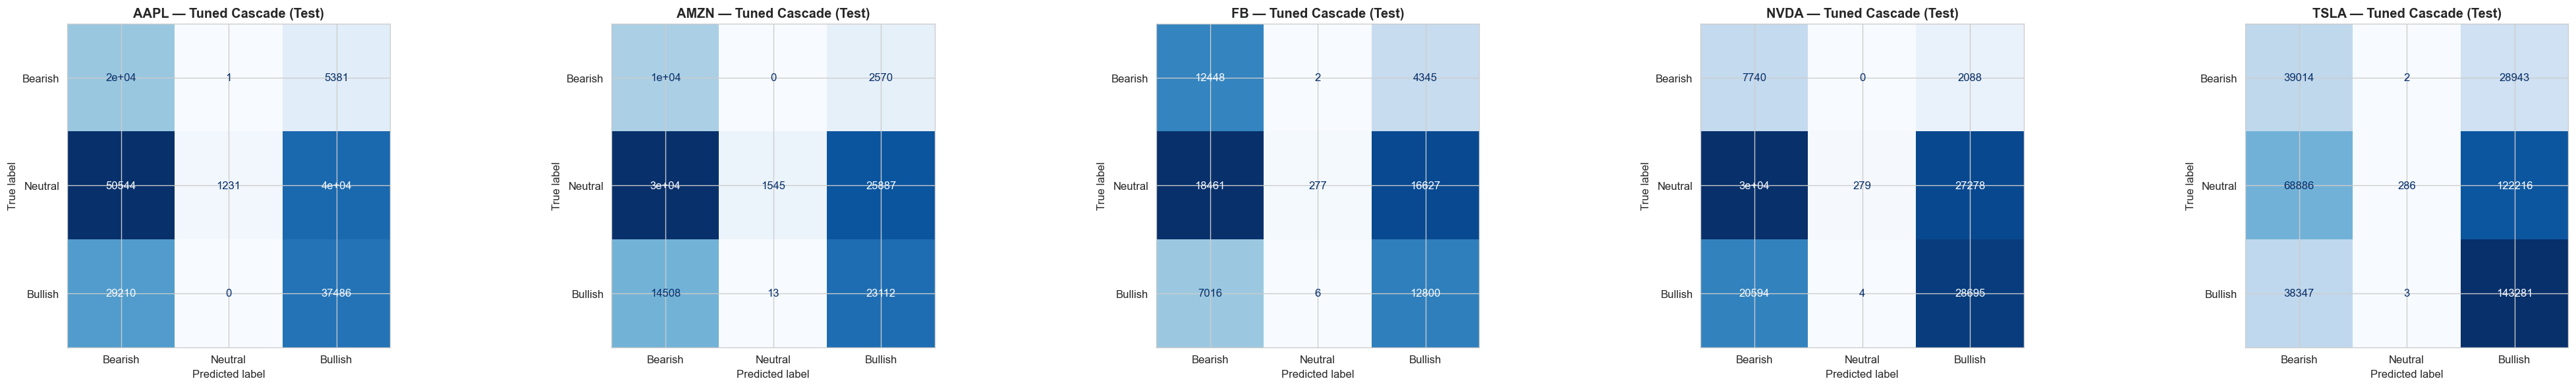

Saved final_confusion_matrices.png


In [22]:
# ── 13b  Final Confusion Matrices ───────────────────────────────────────

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(STOCKS), figsize=(7 * len(STOCKS), 5))
if len(STOCKS) == 1:
    axes = [axes]

class_labels = ["Bearish", "Neutral", "Bullish"]
class_order  = [-1, 0, 1]

for ax, stock in zip(axes, STOCKS):
    rpt = final_report[stock]
    cm = confusion_matrix(rpt["y_test"], rpt["predictions"], labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{stock} — Tuned Cascade (Test)", fontweight="bold")

plt.tight_layout()
plt.savefig("final_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved final_confusion_matrices.png")